
✅ Example Rows with Exit Year and Reason:
    EmployeeNumber  YearsAtCompany  ApproxExitYear  \
0                1               6            2010   
2                4               0            2016   
14              19               4            2012   
21              27               5            2011   
24              31               4            2012   

                                     LikelyReason  
0   Poor Work-Life Balance, Poor Work Environment  
2                                           Other  
14                                   Long Commute  
21                           Low Job Satisfaction  
24    Low Job Satisfaction, Poor Work Environment  


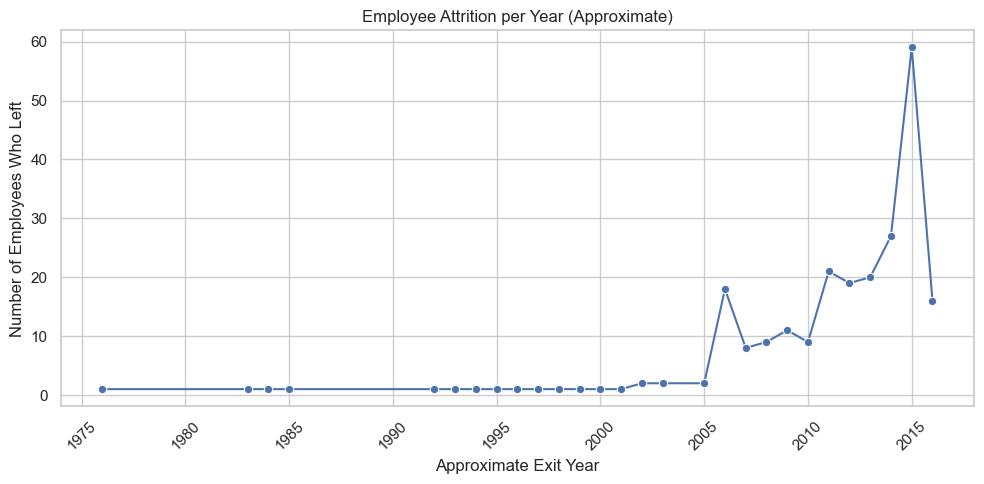

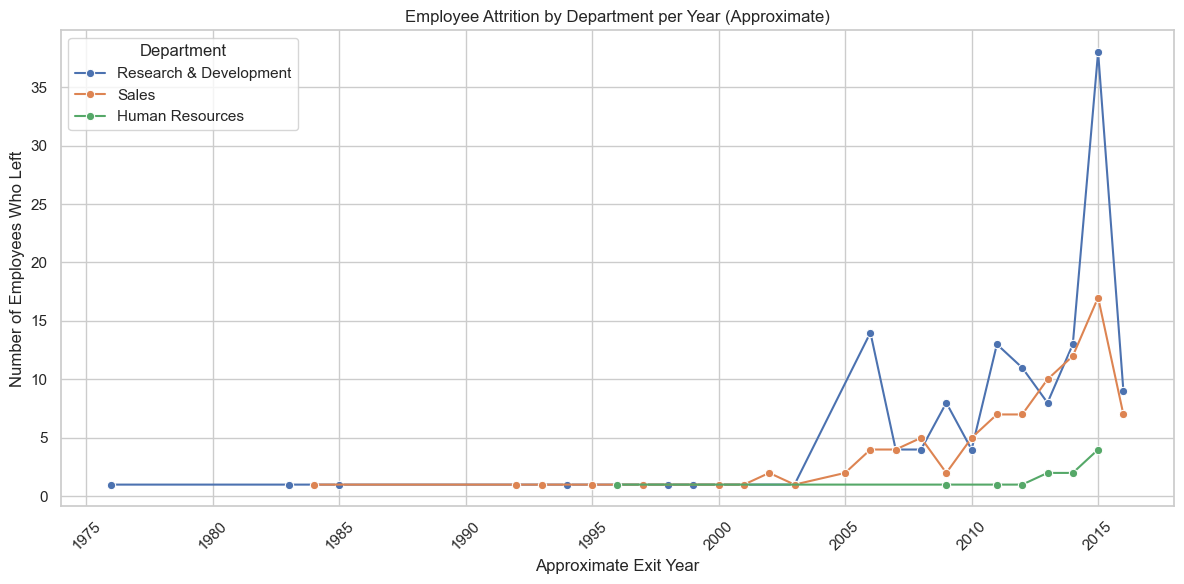


✅ Top Likely Reasons for Attrition:
                                                Count  count
0         Low Job Satisfaction, Poor Work Environment     28
1                                               Other     25
2                               Poor Work Environment     22
3                                Low Job Satisfaction     20
4                              Poor Work-Life Balance     16
5       Poor Work-Life Balance, Poor Work Environment     14
6        Low Job Satisfaction, Poor Work-Life Balance     12
7                                    No Career Growth      9
8   Low Job Satisfaction, Poor Work-Life Balance, ...      9
9                  Low Job Satisfaction, Long Commute      9
10  Low Job Satisfaction, Poor Work Environment, L...      7
11  Low Job Satisfaction, Poor Work Environment, N...      7
12           Poor Work-Life Balance, No Career Growth      7
13                Poor Work Environment, Long Commute      7
14             Low Job Satisfaction, No Career G

C:\Users\Venkateswarlu\AppData\Local\Temp\ipykernel_26988\3393889284.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


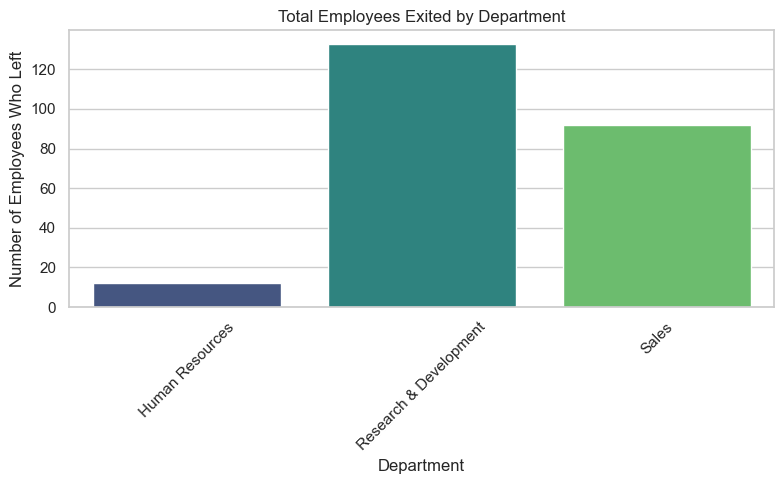


✅ Total Employees Left by Year:
    ApproxExitYear  EmployeesLeft
0             1976              1
1             1983              1
2             1984              1
3             1985              1
4             1992              1
5             1993              1
6             1994              1
7             1995              1
8             1996              1
9             1997              1
10            1998              1
11            1999              1
12            2000              1
13            2001              1
14            2002              2
15            2003              2
16            2005              2
17            2006             18
18            2007              8
19            2008              9
20            2009             11
21            2010              9
22            2011             21
23            2012             19
24            2013             20
25            2014             27
26            2015             59
27            2

C:\Users\Venkateswarlu\AppData\Local\Temp\ipykernel_26988\3393889284.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


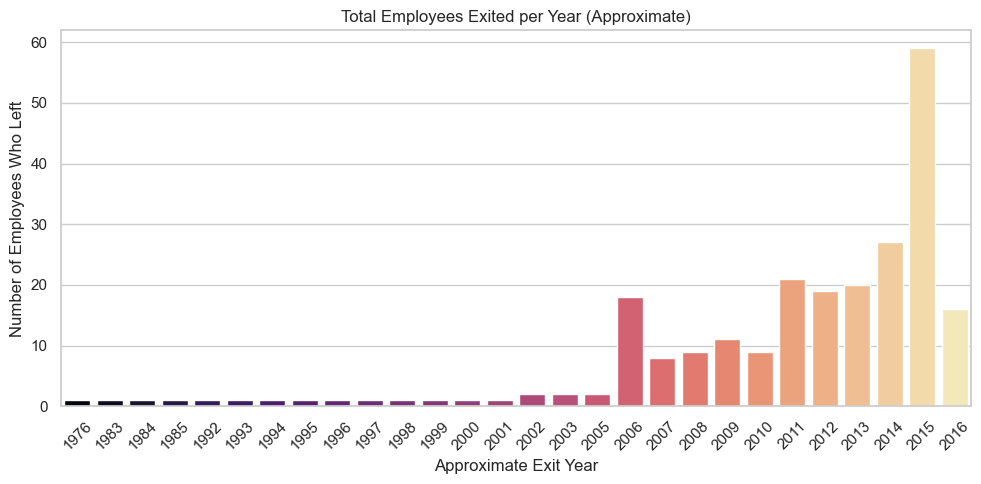

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv(r"C:\Users\Venkateswarlu\Downloads\IBM_HR_Data.csv")

SNAPSHOT_YEAR = 2016

attrition_df = df[df['Attrition'] == 'Yes'].copy()
attrition_df['ApproxExitYear'] = SNAPSHOT_YEAR - attrition_df['YearsAtCompany']
attrition_df['ApproxCareerStartYear'] = SNAPSHOT_YEAR - attrition_df['TotalWorkingYears']

def infer_reason(row):
    reasons = []
    if pd.notnull(row.get('JobSatisfaction')) and row['JobSatisfaction'] <= 2:
        reasons.append('Low Job Satisfaction')
    if pd.notnull(row.get('WorkLifeBalance')) and row['WorkLifeBalance'] <= 2:
        reasons.append('Poor Work-Life Balance')
    if pd.notnull(row.get('EnvironmentSatisfaction')) and row['EnvironmentSatisfaction'] <= 2:
        reasons.append('Poor Work Environment')
    if pd.notnull(row.get('YearsSinceLastPromotion')) and row['YearsSinceLastPromotion'] >= 3:
        reasons.append('No Career Growth')
    if pd.notnull(row.get('DistanceFromHome')) and row['DistanceFromHome'] >= 20:
        reasons.append('Long Commute')
    if not reasons:
        reasons.append('Other')
    return ', '.join(reasons)

attrition_df['LikelyReason'] = attrition_df.apply(infer_reason, axis=1)

exit_per_year = (
    attrition_df
    .groupby('ApproxExitYear')
    .size()
    .reset_index(name='EmployeesLeft')
)

exit_per_year_dept = (
    attrition_df
    .groupby(['ApproxExitYear', 'Department'])
    .size()
    .reset_index(name='EmployeesLeft')
)

print("\n✅ Example Rows with Exit Year and Reason:")
print(attrition_df[['EmployeeNumber', 'YearsAtCompany', 'ApproxExitYear', 'LikelyReason']].head())

plt.figure(figsize=(10, 5))
sns.lineplot(data=exit_per_year, x='ApproxExitYear', y='EmployeesLeft', marker='o')
plt.title('Employee Attrition per Year (Approximate)')
plt.xlabel('Approximate Exit Year')
plt.ylabel('Number of Employees Who Left')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=exit_per_year_dept,
    x='ApproxExitYear',
    y='EmployeesLeft',
    hue='Department',
    marker='o'
)
plt.title('Employee Attrition by Department per Year (Approximate)')
plt.xlabel('Approximate Exit Year')
plt.ylabel('Number of Employees Who Left')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Department')
plt.tight_layout()
plt.show()

reason_counts = (
    attrition_df['LikelyReason']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'LikelyReason', 'LikelyReason': 'Count'})
)

print("\n✅ Top Likely Reasons for Attrition:")
print(reason_counts)

total_exit_by_department = (
    attrition_df
    .groupby('Department')
    .size()
    .reset_index(name='EmployeesLeft')
)

print("\n✅ Total Employees Left by Department:")
print(total_exit_by_department)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=total_exit_by_department,
    x='Department',
    y='EmployeesLeft',
    palette='viridis'
)
plt.title('Total Employees Exited by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees Who Left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

total_exit_by_year = (
    attrition_df
    .groupby('ApproxExitYear')
    .size()
    .reset_index(name='EmployeesLeft')
)

print("\n✅ Total Employees Left by Year:")
print(total_exit_by_year)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=total_exit_by_year,
    x='ApproxExitYear',
    y='EmployeesLeft',
    palette='magma'
)
plt.title('Total Employees Exited per Year (Approximate)')
plt.xlabel('Approximate Exit Year')
plt.ylabel('Number of Employees Who Left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
